/home/markfu/jupyterlab_env/lib/python3.11/site-packages/gpiozero/input_devices.py:852: PWMSoftwareFallback: For more accurate readings, use the pigpio pin factory.See https://gpiozero.readthedocs.io/en/stable/api_input.html#distancesensor-hc-sr04 for more info
  warnings.warn(PWMSoftwareFallback(


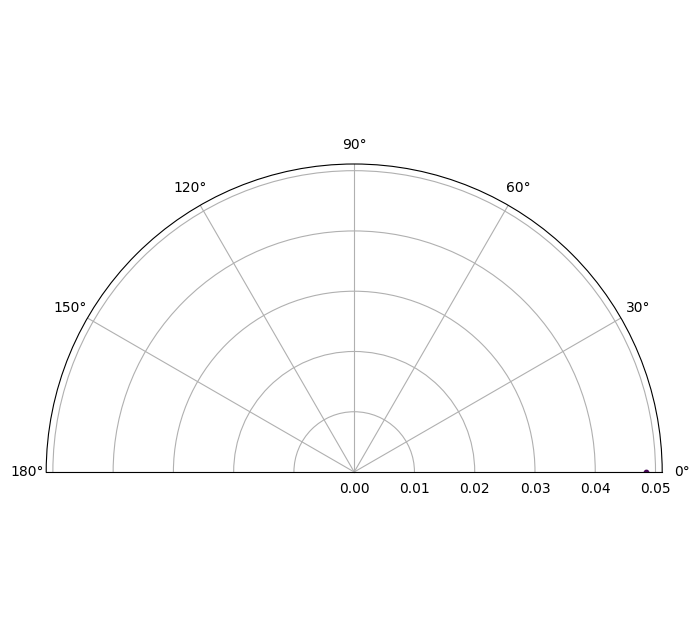

User Keyboard Interrupt : RpiMotorLib: 
User Keyboard Interrupt : RpiMotorLib: 
User Keyboard Interrupt : RpiMotorLib: 
User Keyboard Interrupt : RpiMotorLib: 
User Keyboard Interrupt : RpiMotorLib: 
User Keyboard Interrupt : RpiMotorLib: 
User Keyboard Interrupt : RpiMotorLib: 
User Keyboard Interrupt : RpiMotorLib: 


In [ ]:
#Stepmotor, have motor pins be on GPIO 17,18,19,20.
#Ultrasonic Sensor, have trig pin be 23 and ech 24.
from RpiMotorLib.RpiMotorLib import BYJMotor
import RPi.GPIO as GPIO
import matplotlib.pyplot as plt
import numpy as np
import time
from gpiozero import DistanceSensor

# --- Setup ---
GPIO.setmode(GPIO.BCM)
motor_pins = [17, 18, 19, 20]
trig_pin = 23
echo_pin = 24

ultrasonic = DistanceSensor(trigger=trig_pin, echo=echo_pin)

motor = BYJMotor("stepper", "28BYJ48")

# Radar Data
angles = []
distances = []

def live_radar():
    global angles, distances
    plt.ion()
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='polar')
    
    total_steps = 256 #180 degree radar
    step_delay = 0.003
    
    try:
        while True:
            for s in range(total_steps):
                motor.motor_run(motor_pins, step_delay, 1, False, False, "half", 0)
                
                current_angle = (s / 512) * 2 * np.pi
                dist = ultrasonic.distance
                
                angles.append(current_angle)
                distances.append(dist)
                
                if s % 5 == 0:
                    ax.clear()
                    ax.set_thetamin(0)
                    ax.set_thetamax(180)
                    ax.scatter(angles, distances, c=distances, cmap='viridis', s=10)
                    plt.pause(0.001)
            angles, distances = [], []
            motor.motor_run(motor_pins, step_delay, total_steps, True, False, "half", 0.05)

    except KeyboardInterrupt:
        print("Radar Stopped.")
    finally:
        GPIO.cleanup()
        plt.ioff()
        plt.show()
        ultrasonic.close()

if __name__ == "__main__":
    live_radar()